# HW02-1：股票收益与组合风险分析

- 姓名：邰尚
- 学号：23341044
- 数据来源、获取日期与样本期间：CSMAR 数据库“个股交易数据—日个股回报率文件”；获取日期为 2026-09-24；原始数据覆盖 2020-12-31 至 2026-09-16，正式评价期间为 2021-01-04 至 2026-09-16。其中 2020-12-31 用于计算首个交易日收益率和上一交易日市值权重。
- AI 使用声明：使用了 Codex 辅助理解作业要求、核对数据处理口径、整理 Stata 代码和撰写报告初稿；数据下载、代码运行和结果核验由本人完成并确认。

本报告选择 10 只 A 股股票，覆盖通信、家电、汽车、电力设备、医药、食品饮料、公用事业、非银金融、银行和有色金属等行业。分析目标是：在统一收益率口径下，比较个股收益、风险和相关性，并构造等权组合与市值加权组合，考察分散投资和权重集中对组合风险收益表现的影响。报告先进行主键、日期、缺失和交易日缺口检查，再计算日收益率、累计净值、滚动波动率、描述统计和相关系数，最后比较两类组合的累计净值、几何年化收益率、年化波动率和最大回撤。

## 1. 样本选择与数据口径

### Step 1：Markdown 分析说明

本环节说明样本股票和关键变量口径。选股时尽量覆盖不同业务属性和风险来源，避免样本只反映某一行业表现。收益率主口径采用 CSMAR 的 `Dretwd`，即考虑现金红利再投资的日个股回报率；不复权收盘价 `Clsprc` 只用于画价格时序图，不用于计算收益率和组合收益。

分析要点：

- 样本包含 10 只股票，覆盖 10 个行业，满足至少 5 个行业的要求。
- 正式评价期间为 2021-01-04 至 2026-09-16。
- 市值加权组合使用上一交易日总市值 `Dsmvtll[_n-1]`，不用流通市值，也不用当天市值回填历史权重。
- 不复权价格会受到除权除息影响，不能直接用于收益率计算。

### Step 2：代码与实际输出

样本股票如下：

| 股票代码 | 简称 | 行业 | 选股理由 |
| --- | --- | --- | --- |
| 000063 | 中兴通讯 | 通信 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 000333 | 美的集团 | 家用电器 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 002594 | 比亚迪 | 汽车 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 300750 | 宁德时代 | 电力设备 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 600276 | 恒瑞医药 | 医药生物 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 600519 | 贵州茅台 | 食品饮料 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 600900 | 长江电力 | 公用事业 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 601318 | 中国平安 | 非银金融 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 601398 | 工商银行 | 银行 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |
| 601899 | 紫金矿业 | 有色金属 | 行业代表性较强，样本期前已上市，交易数据覆盖较完整 |

In [ ]:
clear all
set more off

use "data/十只股票.dta", clear
local out "results"
capture mkdir "`out'"

format stkcd %06.0f
format date %tdCY-N-D
gen stkcd_str = string(stkcd, "%06.0f")

egen stkcd_panel = group(stkcd_str), label

order stkcd stkcd_str stkcd_panel date
describe

### Step 3：结果解读

10 只股票覆盖传统消费、金融、先进制造、资源品和公用事业等不同风险来源。这样构造样本的好处是，后续相关性和组合分析可以观察分散投资效果，而不是只比较同一行业内部股票。收益率口径统一使用 `Dretwd`，能把现金分红再投资纳入收益计算，避免用不复权收盘价造成除权除息日的虚假跳变。

## 2. 数据检查与收益率处理

### Step 1：Markdown 分析说明

本环节检查主键、日期排序、有效观测数、缺失和交易日缺口。老师要求不能把所有缺失收益率直接填零，也不能删掉缺失日期后把跨日价格变化当成单日收益。因此，本报告先建立市场交易日序号，再识别个股自身缺失交易日。若某股票缺少市场交易日，则缺口后的第一条收益率不作为普通单日收益率使用。

检查事项：

- `stkcd + date` 是否唯一。
- 样本覆盖期和有效收益率观测数是否足够。
- 是否存在交易日缺口、停牌或其他异常。
- `Dretwd` 与 `Adjprcwd` 自算收益率是否一致。

In [ ]:
* 生成市场交易日序号，用于识别股票自身交易日缺口
preserve
keep date
duplicates drop
sort date
gen mkt_day = _n
tempfile trading_calendar
save `trading_calendar'
restore

merge m:1 date using `trading_calendar', nogen
sort stkcd date
bysort stkcd (date): gen mkt_gap = mkt_day - mkt_day[_n-1]

* 统一分析变量
gen ret = Dretwd
gen close = Clsprc
gen amount = Dnvaltrd
gen mv_total = Dsmvtll
gen adjclose = Adjprcwd

* 对缺口后的第一条收益率做处理，避免把跨期收益当作单日收益
gen ret_single = ret
replace ret_single = . if date >= td(04jan2021) & mkt_gap > 1

* 覆盖期和有效观测数
bysort stkcd: egen first_date = min(date)
bysort stkcd: egen last_date = max(date)
bysort stkcd: gen n_obs = _N
format first_date last_date %tdCCYY-NN-DD

preserve
keep stkcd_str first_date last_date n_obs
duplicates drop
list stkcd_str first_date last_date n_obs, noobs clean
restore

* 主键、缺失和交易状态检查
duplicates report stkcd date
misstable summarize close amount mv_total ret adjclose
tab Trdsta, missing

实际检查结果如下：

| 股票代码 | 简称 | 起始日期 | 结束日期 | 原始观测数 | 有效日收益数 |
| --- | --- | --- | --- | --- | --- |
| 000063 | 中兴通讯 | 2020-12-31 | 2026-09-16 | 1384 | 1382 |
| 000333 | 美的集团 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 002594 | 比亚迪 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 300750 | 宁德时代 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 600276 | 恒瑞医药 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 600519 | 贵州茅台 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 600900 | 长江电力 | 2020-12-31 | 2026-09-16 | 1374 | 1371 |
| 601318 | 中国平安 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 601398 | 工商银行 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |
| 601899 | 紫金矿业 | 2020-12-31 | 2026-09-16 | 1385 | 1384 |

交易日缺口后的收益率处理如下：

| 股票代码 | 简称 | 缺口后日期 | 跨越市场交易日数 | 原始收益率（%） |
| --- | --- | --- | --- | --- |
| 000063 | 中兴通讯 | 2021-04-01 | 2.000 | 0.239 |
| 600900 | 长江电力 | 2021-12-13 | 11.000 | 6.810 |
| 600900 | 长江电力 | 2022-10-27 | 2.000 | -4.634 |

In [ ]:
* 收益率口径核验：Dretwd 与复权可比价格计算收益率应基本一致
sort stkcd date
bysort stkcd (date): gen ret_from_adj = adjclose / adjclose[_n-1] - 1
bysort stkcd (date): gen ret_from_close = close / close[_n-1] - 1

gen diff_adj = ret - ret_from_adj
gen diff_close = ret - ret_from_close
summ diff_adj diff_close

gsort -diff_close
list date stkcd_str ret ret_from_adj ret_from_close close adjclose diff_close in 1/15, noobs clean

### Step 3：结果解读

数据主键没有重复，核心价格、成交金额、总市值、复权可比价格和收益率字段没有缺失。10 只股票均覆盖到 2026-09-16，其中大部分股票原始观测数为 1,385；`000063` 少 1 个市场交易日，`600900` 少 11 个市场交易日。为避免把跨期收益误当作单日收益，本报告将缺口后的 `2021-04-01`、`2021-12-13` 和 `2022-10-27` 收益率置为缺失。

收益率口径核验显示，`Dretwd` 与用 `Adjprcwd` 计算的复权收益率基本一致，因此后续分析使用 `Dretwd`。相反，用不复权收盘价计算收益率会在公司行为日产生明显偏差，例如比亚迪在 2025-07-29 若用不复权收盘价计算会出现约 -66.94% 的虚假跌幅。由此可见，不复权收盘价只适合画价格水平，不适合计算收益率。

核心发现：

- 样本覆盖期完整，只有少数交易日缺口。
- 缺口后的跨期收益率已从单日收益率分析中剔除。
- 正式收益率口径采用含现金红利再投资收益率，符合老师要求。
- 之前组合净值图中 2024 年上半年的突兀抬升，不是由不复权收益率造成；更可能来自排序、重复日期或中间数据继续运行等代码流程问题。

## 3. 图形分析：价格、累计收益与日收益率

### Step 1：Markdown 分析说明

本环节分别展示不复权收盘价、起点为 1 的累计净值和日收益率时序。不复权收盘价用于观察价格水平和长期趋势；累计净值使用处理后的 `ret_single` 计算，反映考虑现金红利再投资后的财富增长；日收益率时序用于检查异常波动和不同股票风险差异。

作图口径：

- 收盘价图使用 `Clsprc`，满足“不复权收盘价时序”的要求。
- 累计净值和日收益率图使用 `ret_single`。
- 分面图的股票代码使用六位字符串，避免 `000063` 显示为 `63`。
- 收盘价图使用各分面单独 y 轴，避免不同价格量级挤在一起。

In [ ]:
graph set window fontface "Songti SC"

* 不复权收盘价时序图
twoway line close date, by(stkcd_panel, cols(2) note("") yrescale) ///
    title("10只股票不复权收盘价时序") ///
    xtitle("日期") ytitle("收盘价") ///
    ylabel(#4, angle(0) labsize(vsmall) format(%9.0f)) ///
    xlabel(td(01jan2021) td(01jan2022) td(01jan2023) td(01jan2024) td(01jan2025) td(01jan2026), ///
        format(%tdCCYY-NN-DD) angle(45) labsize(vsmall))
graph export "`out'/个股收盘价时序.png", replace width(2400)

* 个股累计净值
sort stkcd date
gen lnret = ln(1 + ret_single) if date >= td(04jan2021)
replace lnret = 0 if date == td(31dec2020)
bysort stkcd (date): gen nav_stock = exp(sum(lnret))

twoway line nav_stock date, by(stkcd_panel, cols(2) note("") yrescale) ///
    title("10只股票累计净值") ///
    xtitle("日期") ytitle("累计净值") ///
    ylabel(#4, angle(0) labsize(vsmall) format(%4.1f)) ///
    xlabel(td(01jan2021) td(01jan2022) td(01jan2023) td(01jan2024) td(01jan2025) td(01jan2026), ///
        format(%tdCCYY-NN-DD) angle(45) labsize(vsmall))
graph export "`out'/个股累计净值.png", replace width(2400)

* 日收益率时序图
twoway line ret_single date, by(stkcd_panel, cols(2) note("")) ///
    title("10只股票日收益率时序") ///
    xtitle("日期") ytitle("日收益率") ///
    yline(0, lcolor(gs10) lpattern(dash)) ///
    ylabel(-0.20(0.10)0.20, angle(0) labsize(vsmall) format(%4.2f)) ///
    xlabel(td(01jan2021) td(01jan2022) td(01jan2023) td(01jan2024) td(01jan2025) td(01jan2026), ///
        format(%tdCCYY-NN-DD) angle(45) labsize(vsmall))
graph export "`out'/个股日收益率.png", replace width(2400)

### 不复权收盘价时序图

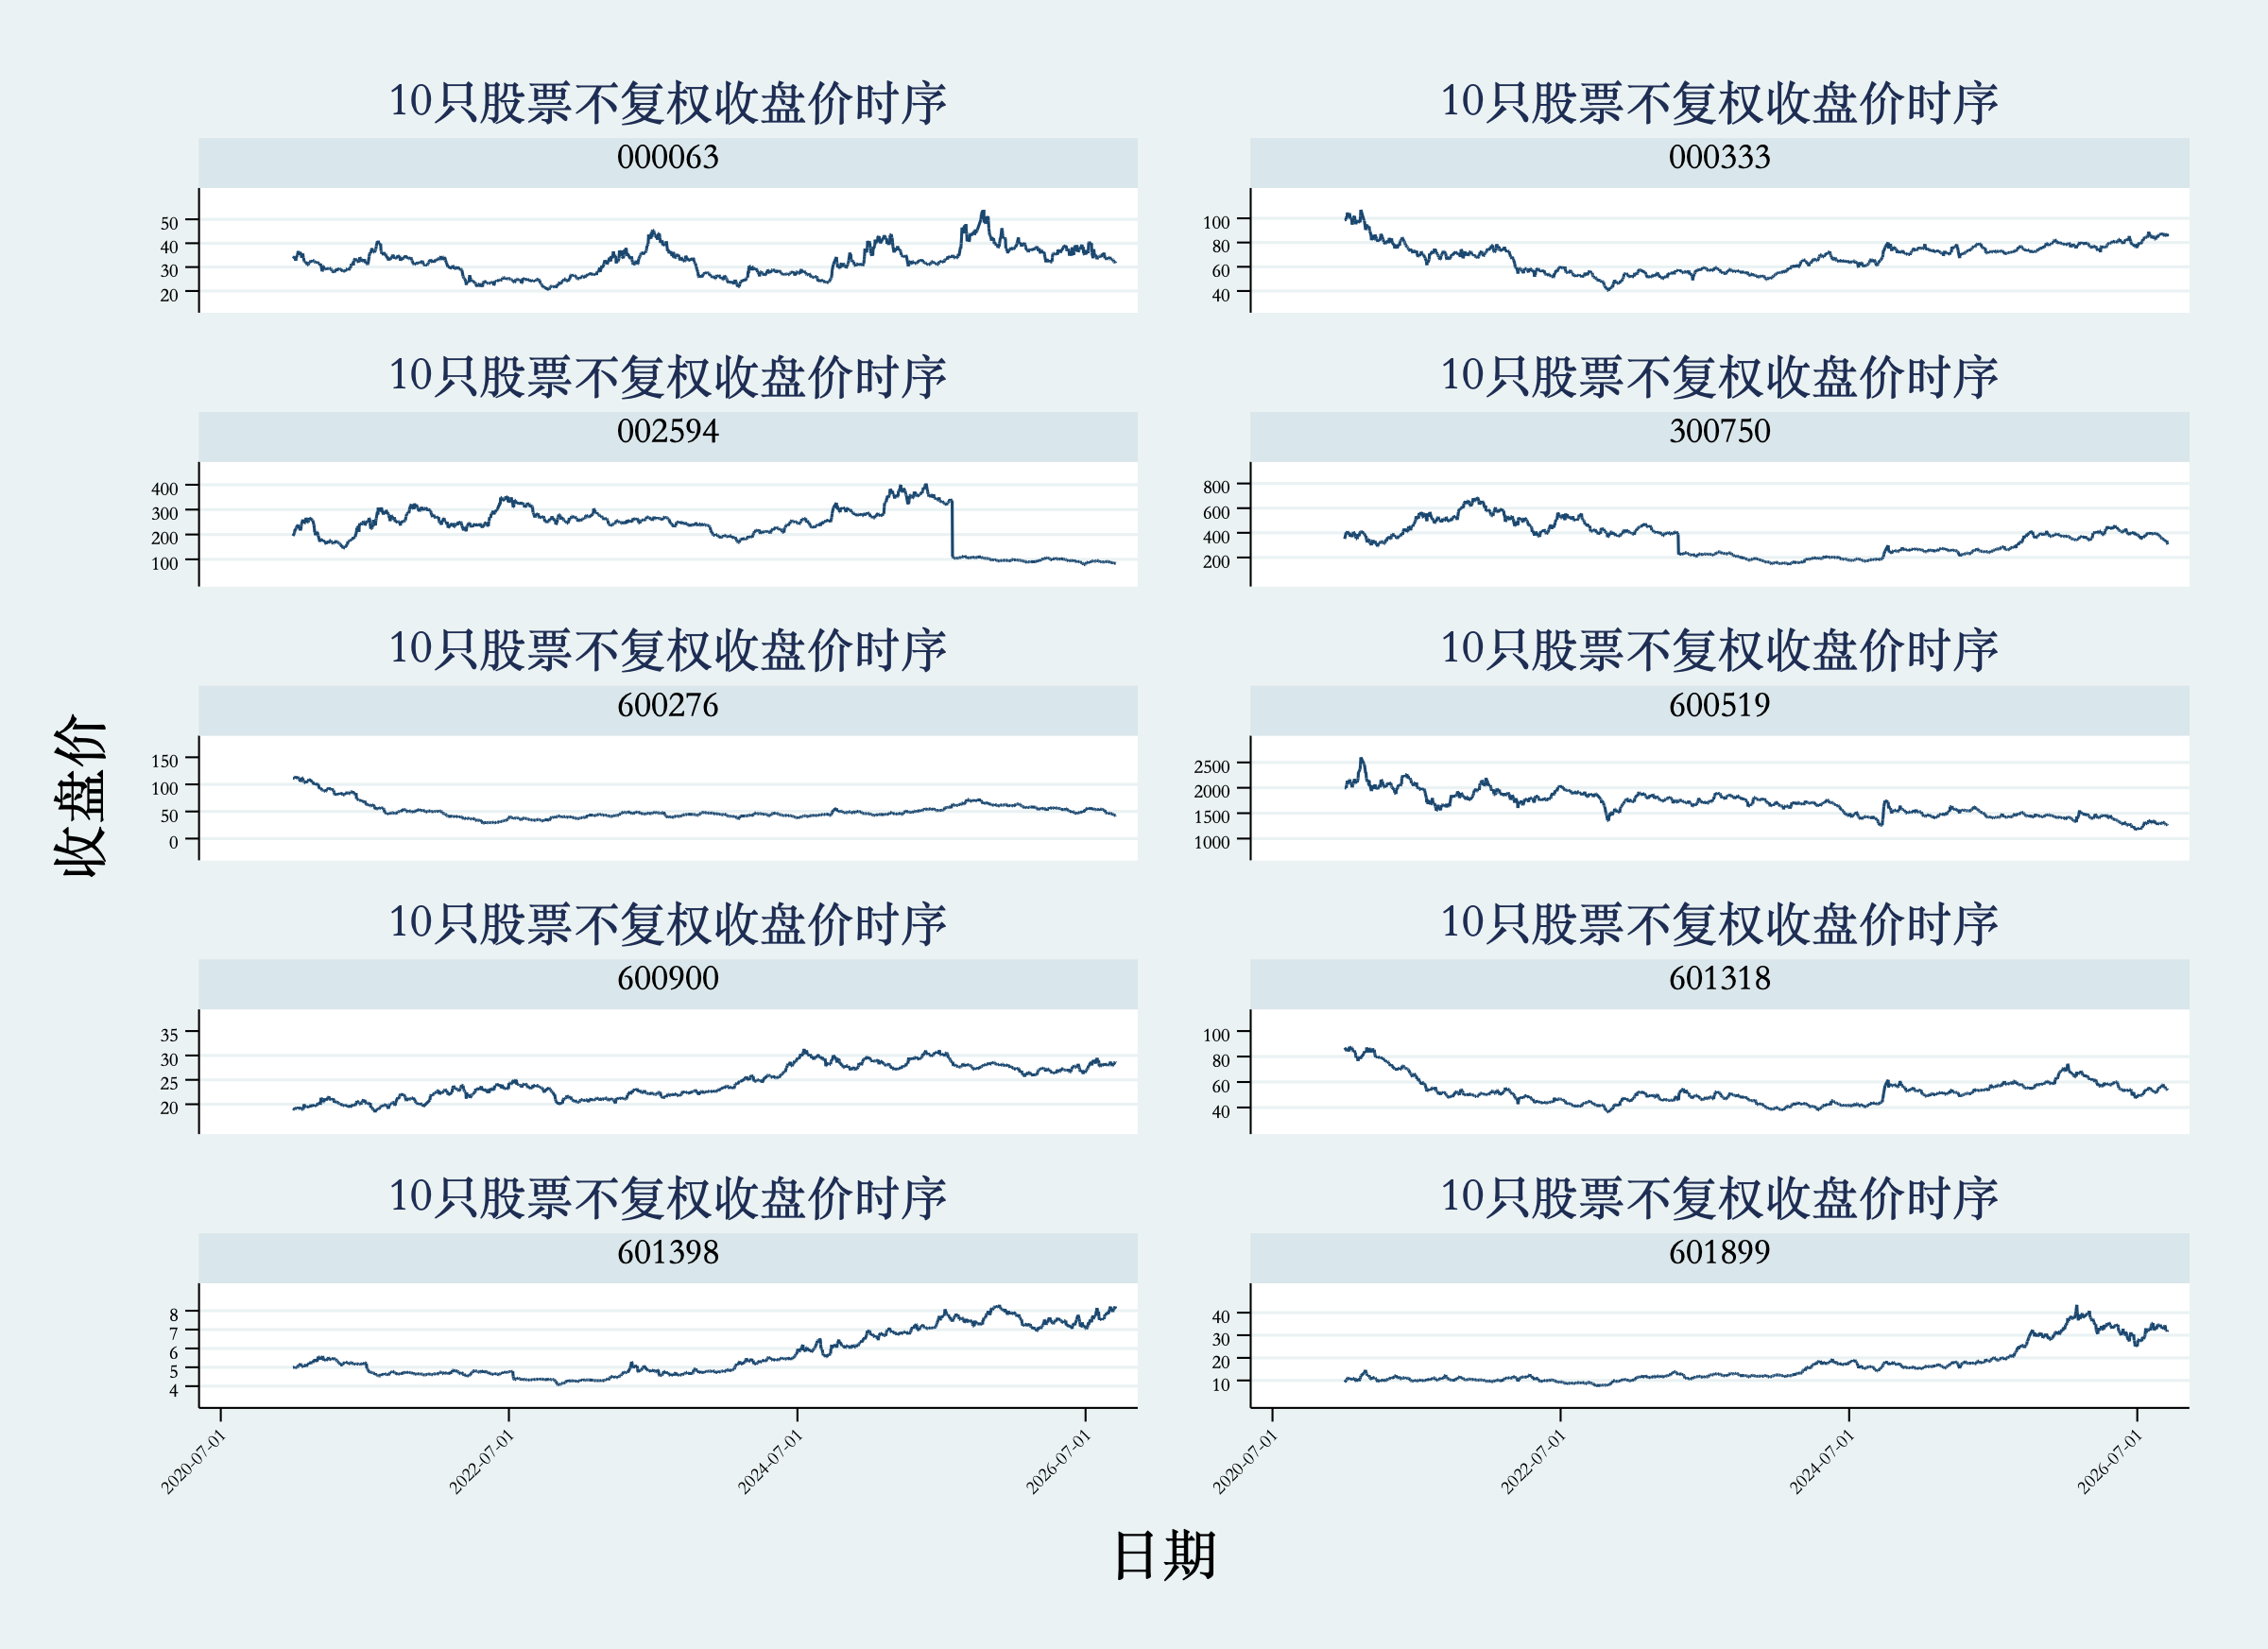

### 个股累计净值图

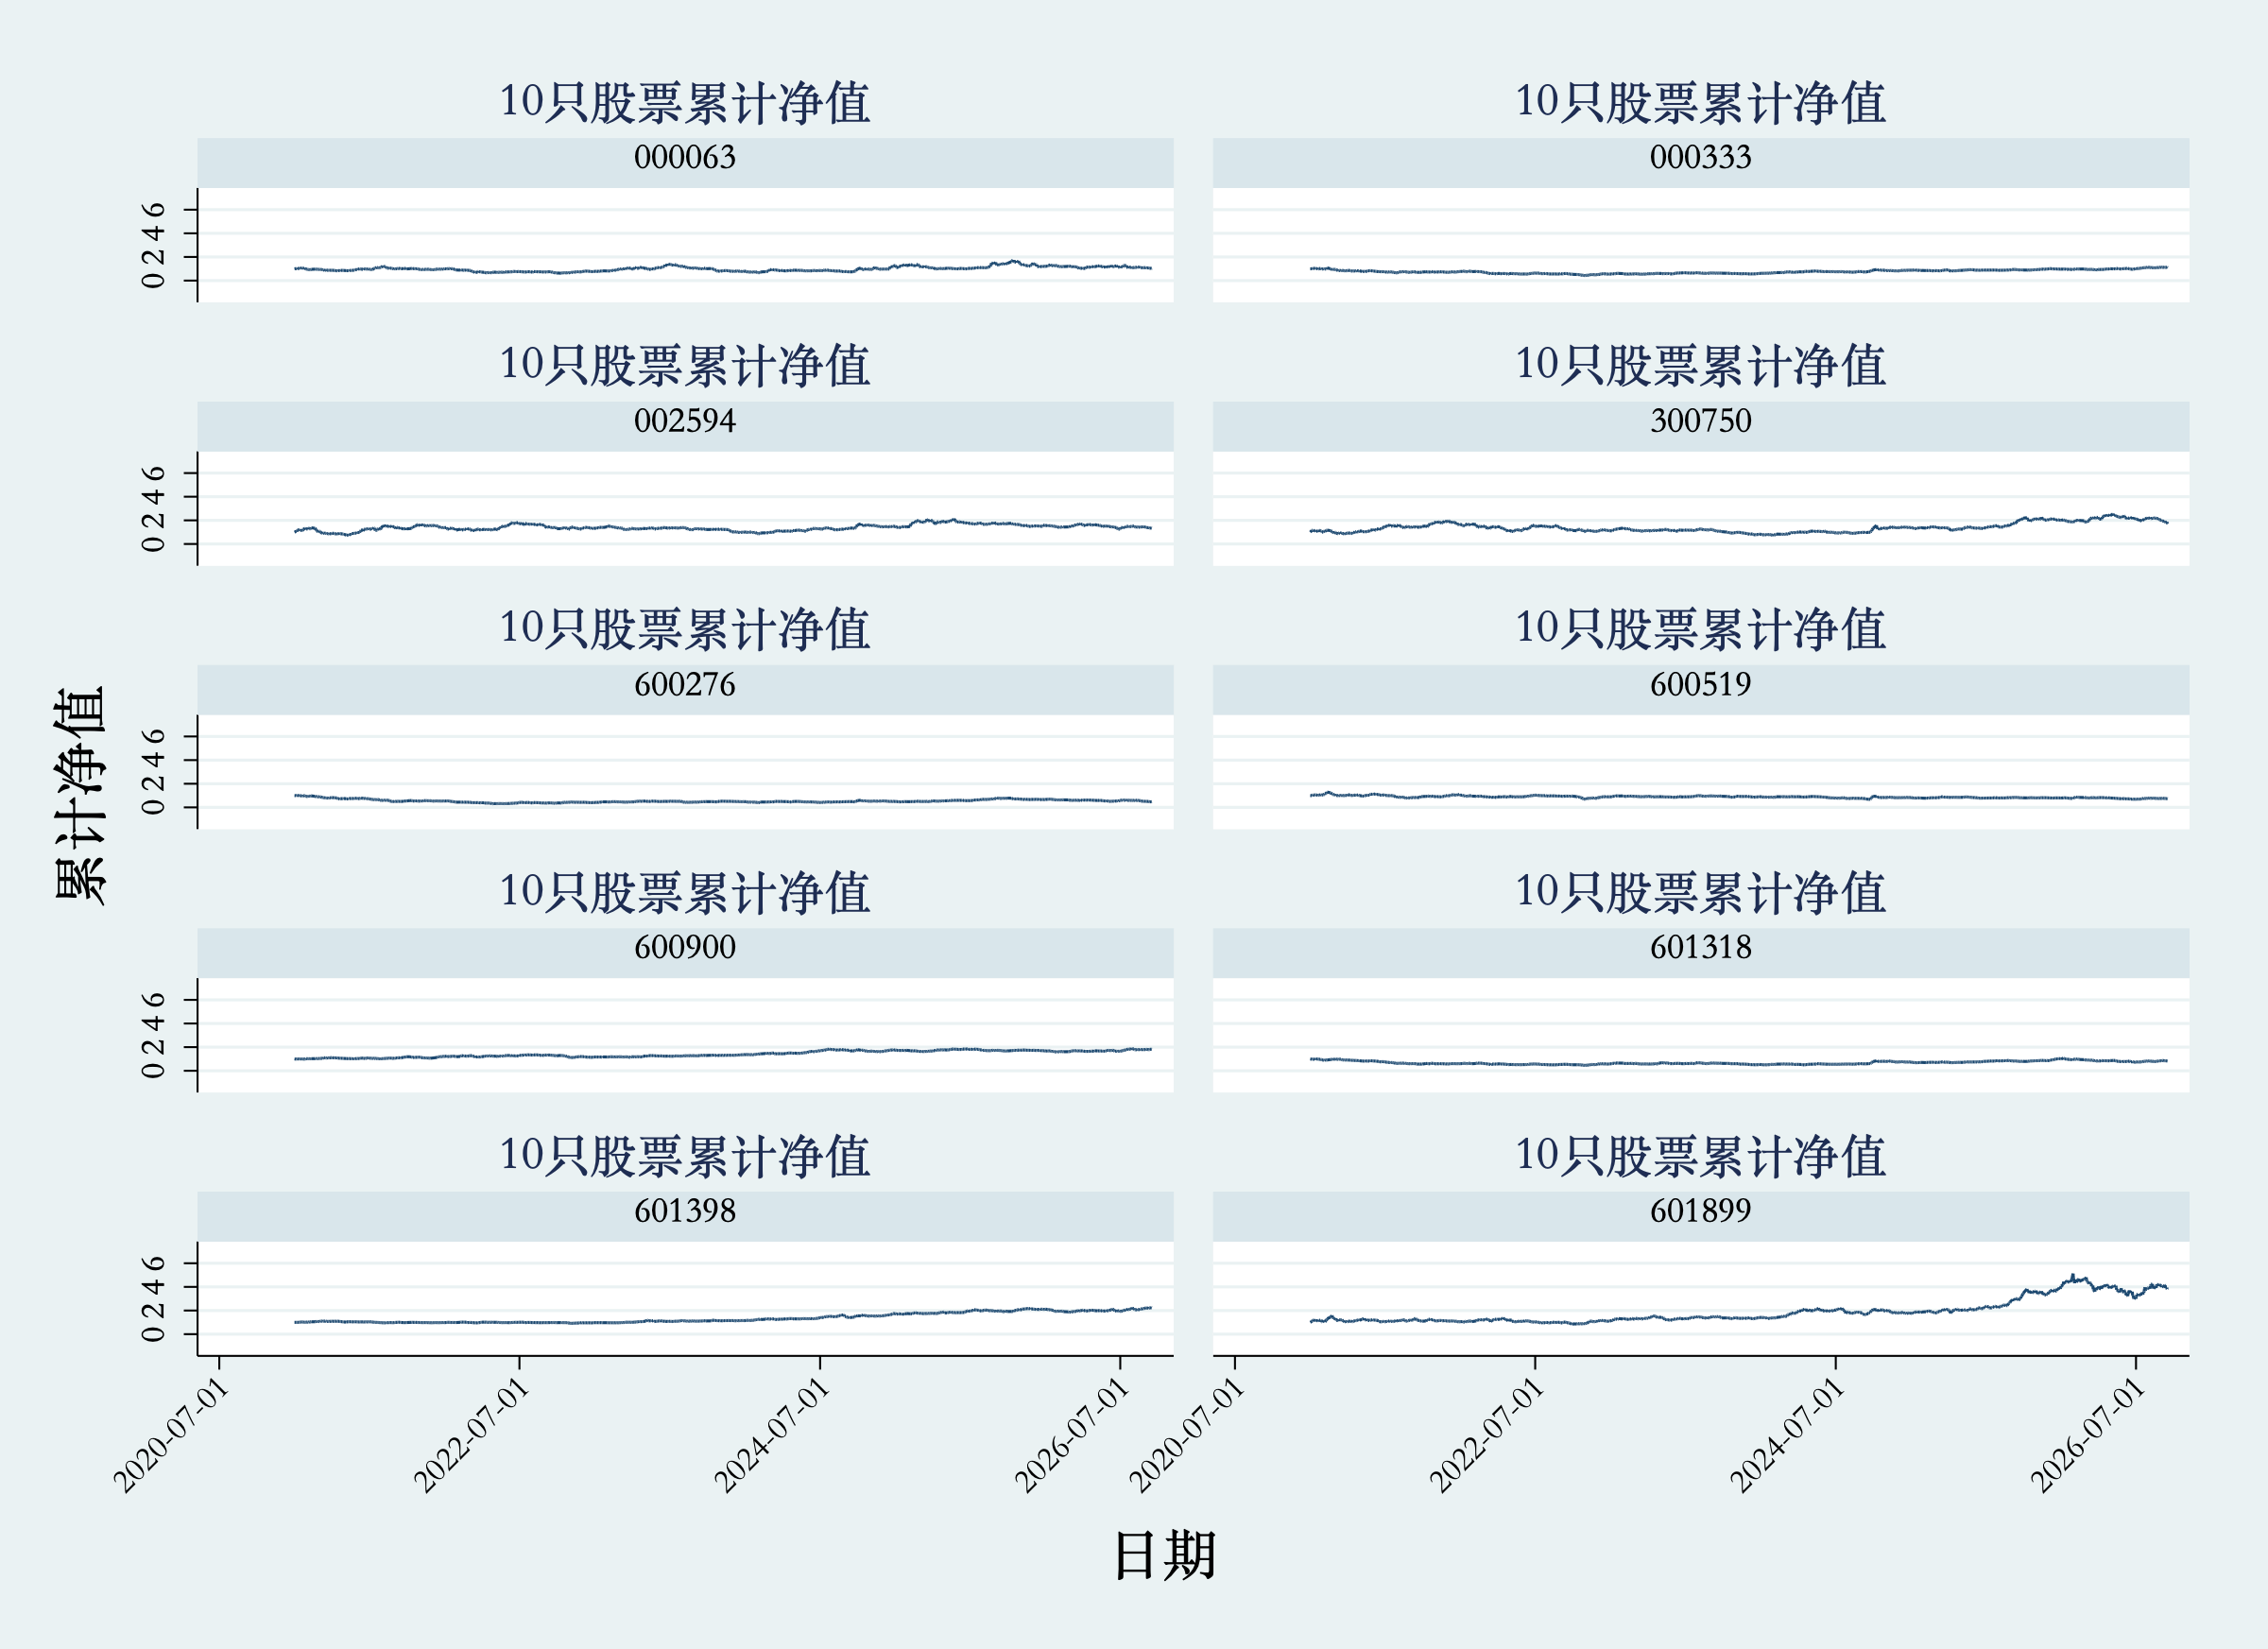

### 日收益率时序图

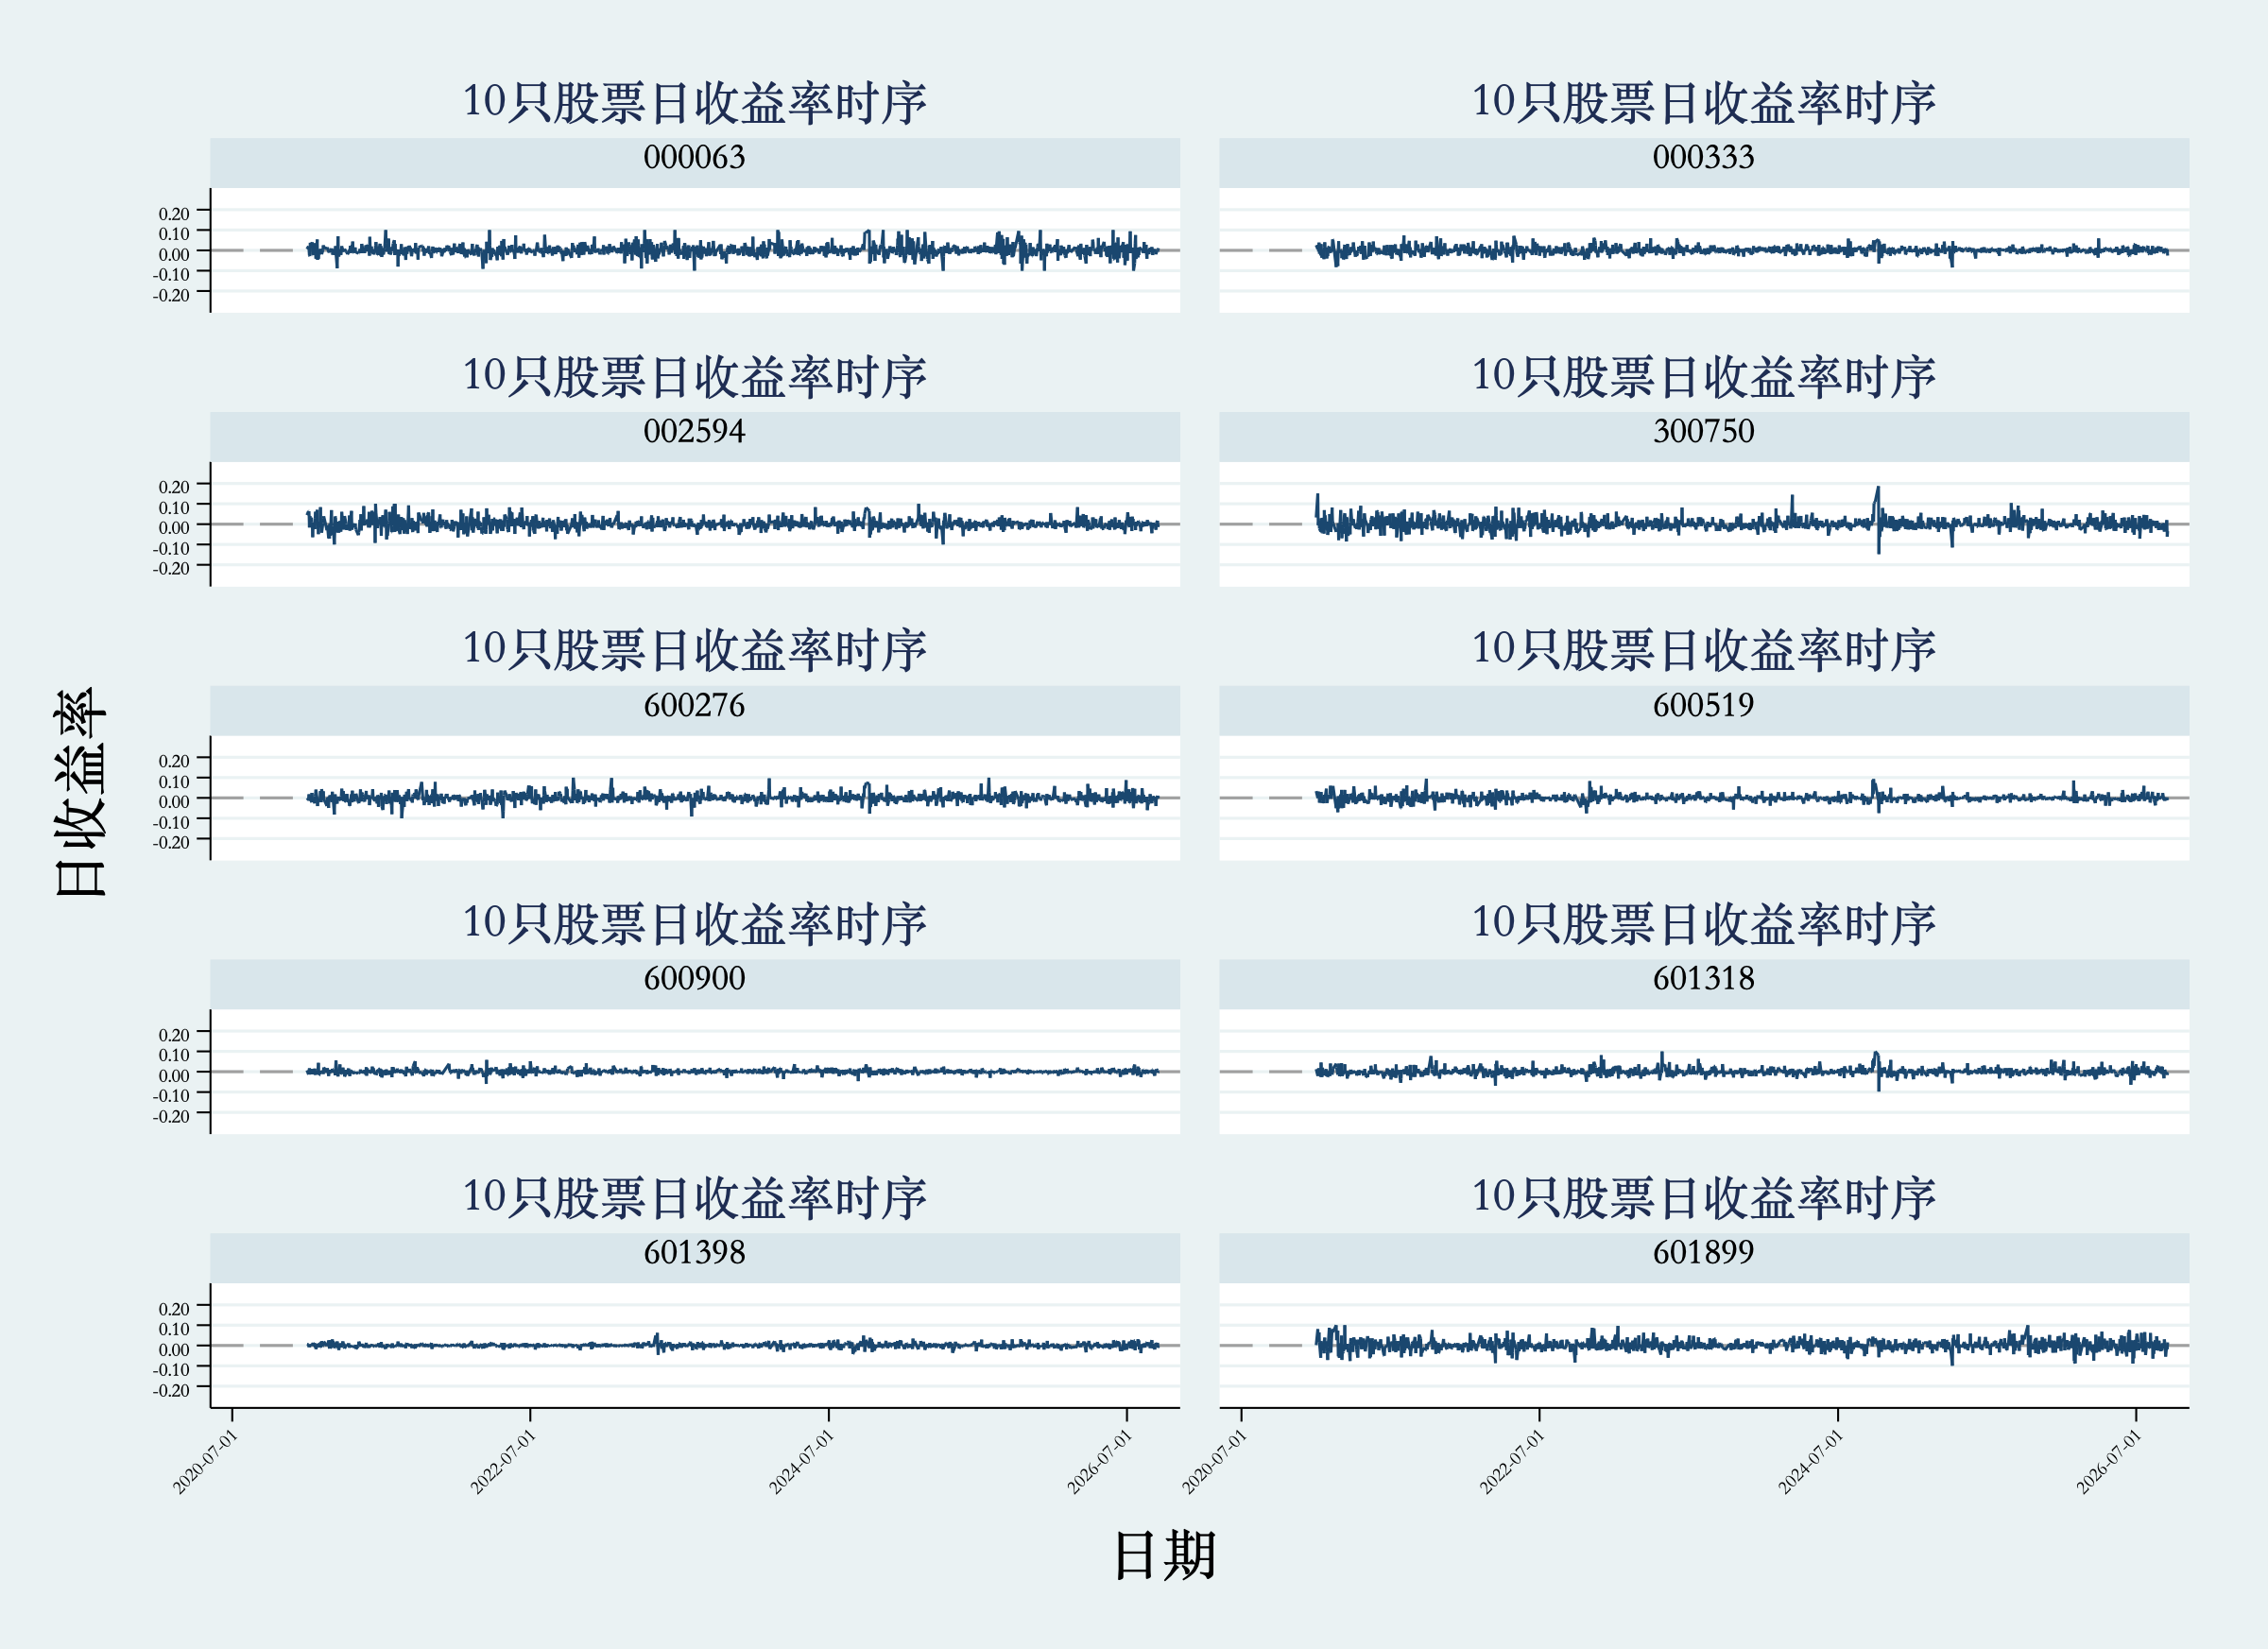

### Step 3：结果解读

从不复权收盘价图看，贵州茅台的价格水平明显高于其他股票，因此价格图采用分面单独纵轴更便于观察各股票自身趋势。累计净值图显示，紫金矿业、宁德时代等股票在样本期内累计表现较突出，但它们的日收益率波动也更明显。银行和公用事业类股票的价格和收益率波动相对平稳，说明其短期风险较低。

日收益率图中，多数股票的日收益率集中在 -10% 至 10% 附近，宁德时代出现过更大的单日正收益，最小日收益率约为 -14.72%，最大日收益率约为 18.70%。这些极端值没有直接删除，而是在后续统计中保留并解释，因为它们更可能反映真实市场波动，而不是明显的数据错误。

核心发现：

- 个股价格水平差异很大，不能用价格高低直接比较收益表现。
- 成长和资源类股票的累计收益弹性更高，但波动也更大。
- 银行和公用事业股票波动较低，具有更强防御性。
- 收益率分析必须使用复权收益率，不能用不复权价格直接计算。

## 4. 滚动波动率、描述统计与相关性

### Step 1：Markdown 分析说明

本环节计算 20 个交易日滚动年化波动率、个股收益率描述统计和 Pearson 相关系数矩阵。滚动波动率用于观察风险随时间变化；描述统计用于比较平均收益、标准差、偏度和超额峰度；相关系数用于衡量股票之间的联动程度。

统计口径：

- 年化波动率 = 日收益率样本标准差 × `sqrt(252)`。
- 滚动窗口为 20 个交易日，不足完整窗口时不计算。
- 描述统计使用 `ret_single`。
- 相关性矩阵使用日收益率 Pearson 相关系数，按日期自动对齐。

In [ ]:
* 20个交易日滚动年化波动率
capture ssc install rangestat
rangestat (count) n20=ret_single (sd) sd20=ret_single, ///
    interval(mkt_day -19 0) by(stkcd)

gen rollvol20 = sd20 * sqrt(252) if n20 == 20

twoway line rollvol20 date, by(stkcd_panel, cols(2) note("") yrescale) ///
    title("20个交易日滚动年化波动率") ///
    xtitle("日期") ytitle("年化波动率") ///
    ylabel(#4, angle(0) labsize(vsmall) format(%4.2f)) ///
    xlabel(td(01jan2021) td(01jan2022) td(01jan2023) td(01jan2024) td(01jan2025) td(01jan2026), ///
        format(%tdCCYY-NN-DD) angle(45) labsize(vsmall))
graph export "`out'/20日滚动年化波动率.png", replace width(2400)

### 20 个交易日滚动年化波动率

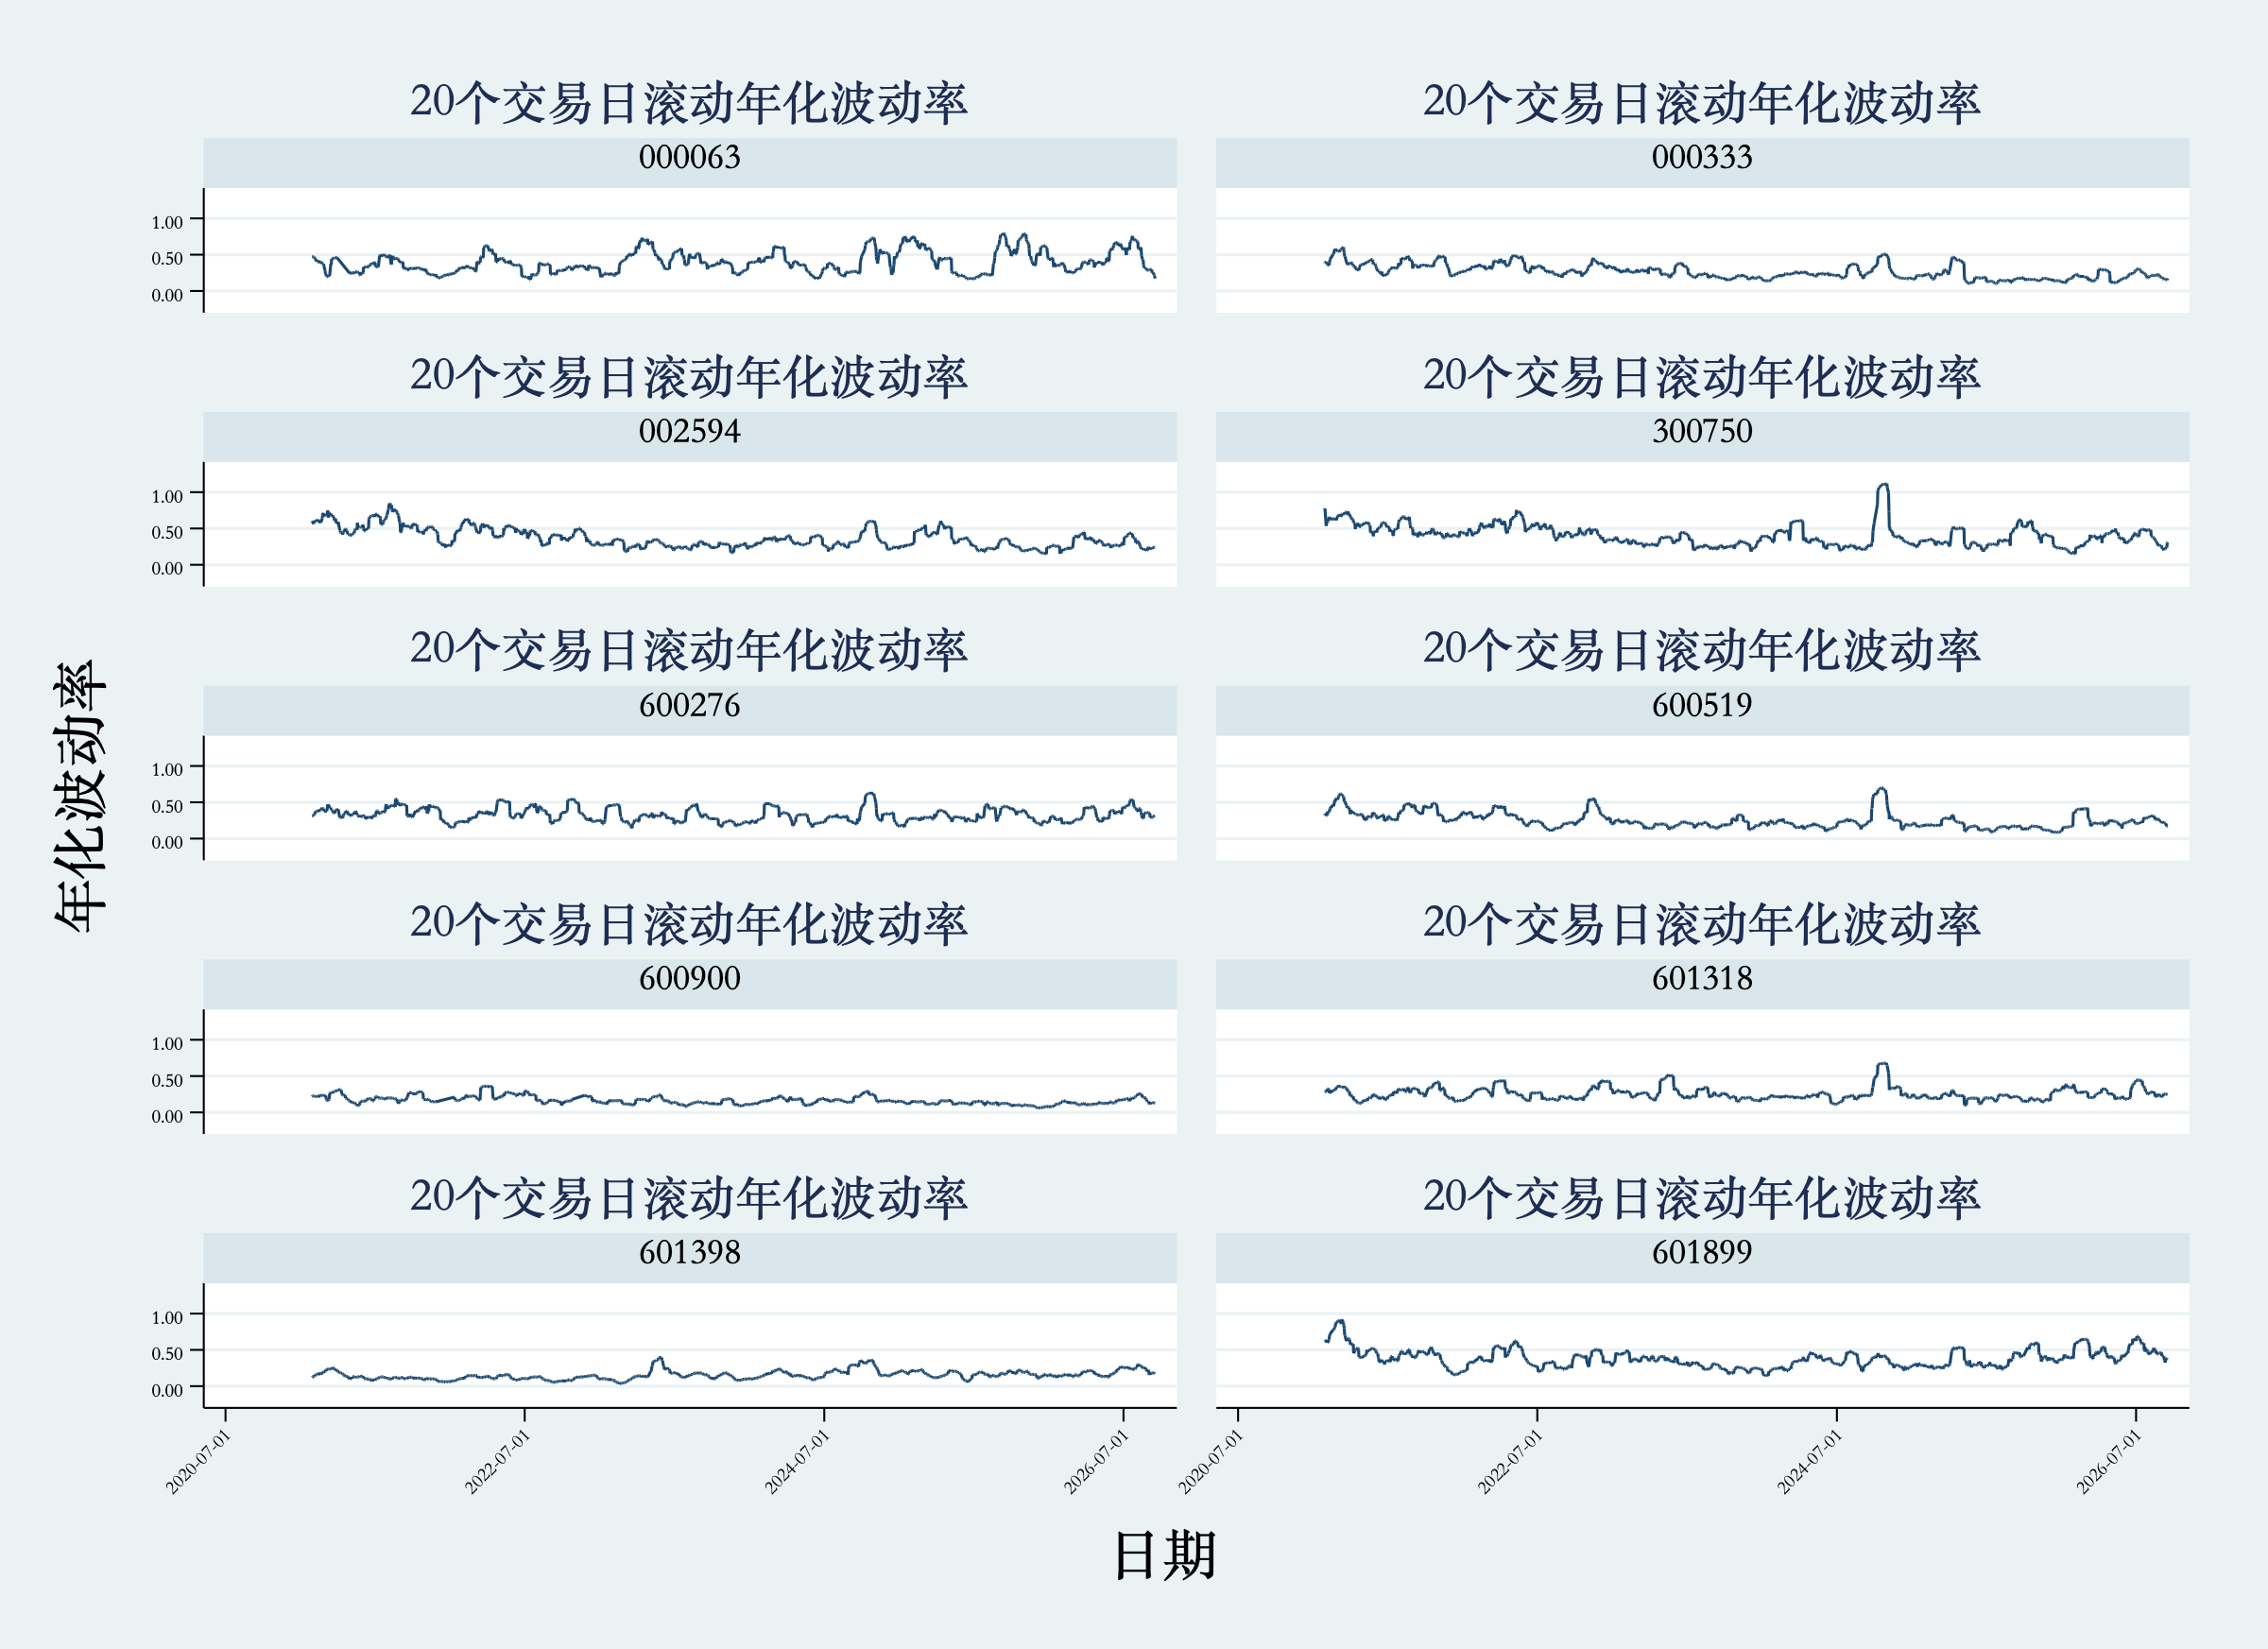

In [ ]:
* 描述统计：有效观测数、均值、标准差、极值、中位数、偏度、超额峰度
preserve
keep if date >= td(04jan2021)
statsby ///
    N=r(N) mean=r(mean) sd=r(sd) min=r(min) median=r(p50) max=r(max) ///
    skewness=r(skewness) kurtosis=r(kurtosis), ///
    by(stkcd_str) clear: summarize ret_single, detail

gen excess_kurtosis = kurtosis - 3
gen ann_vol = sd * sqrt(252)
export delimited using "`out'/个股收益率描述统计.csv", replace
restore

* Pearson相关系数矩阵
preserve
keep if date >= td(04jan2021)
keep date stkcd_str ret_single
reshape wide ret_single, i(date) j(stkcd_str) string
corr ret_single*
matrix C = r(C)
putexcel set "`out'/收益率相关系数矩阵.xlsx", replace
putexcel A1 = matrix(C), names
restore

个股收益率描述统计如下：

| 股票代码 | 简称 | N | 日均收益率（%） | 日收益率标准差（%） | 最小值（%） | 中位数（%） | 最大值（%） | 偏度 | 超额峰度 | 年化波动率（%） |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 000063 | 中兴通讯 | 1382 | 0.039 | 2.665 | -10.012 | -0.097 | 10.016 | 0.419 | 2.508 | 42.300 |
| 000333 | 美的集团 | 1384 | 0.023 | 1.779 | -8.424 | -0.015 | 7.324 | 0.141 | 1.998 | 28.234 |
| 002594 | 比亚迪 | 1384 | 0.051 | 2.464 | -10.002 | -0.129 | 10.001 | 0.471 | 2.088 | 39.113 |
| 300750 | 宁德时代 | 1384 | 0.076 | 2.746 | -14.716 | -0.171 | 18.703 | 0.598 | 3.989 | 43.595 |
| 600276 | 恒瑞医药 | 1384 | -0.030 | 2.140 | -10.000 | -0.157 | 10.000 | 0.372 | 2.900 | 33.976 |
| 600519 | 贵州茅台 | 1384 | -0.008 | 1.717 | -7.557 | -0.095 | 9.504 | 0.584 | 4.333 | 27.251 |
| 600900 | 长江电力 | 1371 | 0.048 | 1.087 | -6.000 | 0.000 | 5.816 | 0.405 | 3.294 | 17.256 |
| 601318 | 中国平安 | 1384 | 0.000 | 1.709 | -9.768 | -0.114 | 10.002 | 0.731 | 4.282 | 27.128 |
| 601398 | 工商银行 | 1384 | 0.063 | 1.038 | -4.554 | 0.000 | 6.212 | 0.164 | 2.653 | 16.484 |
| 601899 | 紫金矿业 | 1384 | 0.130 | 2.513 | -9.936 | 0.106 | 10.017 | 0.169 | 1.520 | 39.895 |

相关性较高的股票组合如下：

| 股票 1 | 股票 2 | 相关系数 |
| --- | --- | --- |
| 002594 | 300750 | 0.575 |
| 600519 | 601318 | 0.493 |
| 000333 | 601318 | 0.462 |
| 000333 | 600519 | 0.454 |
| 600900 | 601398 | 0.423 |

相关性较低或为负的股票组合如下：

| 股票 1 | 股票 2 | 相关系数 |
| --- | --- | --- |
| 300750 | 600900 | 0.000 |
| 000063 | 600900 | -0.032 |
| 300750 | 601398 | -0.059 |
| 002594 | 601398 | -0.059 |
| 000063 | 601398 | -0.102 |

### Step 3：结果解读

描述统计显示，紫金矿业的日均收益率最高，约为 0.130%；宁德时代次之，约为 0.076%。风险方面，宁德时代年化波动率最高，约为 43.60%；中兴通讯和紫金矿业也较高，分别约为 42.30% 和 39.90%。工商银行和长江电力的年化波动率最低，分别约为 16.48% 和 17.26%。这说明高收益样本通常伴随更高波动，但银行、公用事业等低波动股票也可能在组合中起到稳定作用。

相关性矩阵显示，比亚迪和宁德时代的相关系数最高，约为 0.575，符合二者同属新能源产业链的直觉。美的集团、贵州茅台和中国平安之间也有中等相关性，可能反映大盘蓝筹和消费金融风格的共同波动。中兴通讯与工商银行的相关系数约为 -0.102，说明两者在样本期内联动较弱，能提供一定分散化效果。

核心发现：

- 宁德时代、中兴通讯和紫金矿业风险较高，工商银行和长江电力风险较低。
- 比亚迪与宁德时代相关性最高，行业链条相近是可能原因。
- 低相关或负相关股票有助于降低组合风险。
- 个股收益率均有正偏和正超额峰度，说明极端波动不可忽视。

## 5. 等权组合与市值加权组合

### Step 1：Markdown 分析说明

本环节构造等权组合和市值加权组合。等权组合每天给 10 只股票相同权重；市值加权组合每天使用上一交易日总市值计算权重。两类组合均按日目标权重计算收益，并忽略交易成本。

组合分析要点：

- 两个组合使用完全相同的评价期间。
- 市值加权权重使用上一交易日总市值，不使用流通市值。
- 每日市值权重和必须等于 1。
- 组合年化波动率先计算组合日收益率，再乘以 `sqrt(252)`，不能加权平均个股波动率。
- 最大回撤按净值相对历史峰值的最大跌幅计算，报告为非负数。

In [ ]:
* 市值加权组合使用上一交易日总市值
sort stkcd date
bysort stkcd (date): gen mv_lag = mv_total[_n-1]

gen valid_port = inrange(date, td(04jan2021), td(16sep2026)) ///
    & !missing(ret_single, mv_lag) ///
    & mkt_gap == 1
bysort date: egen n_valid = total(valid_port)
keep if valid_port == 1 & n_valid == 10

* 等权组合和市值加权组合日收益率
bysort date: egen ew_ret = mean(ret_single)
bysort date: egen mv_sum = total(mv_lag)
gen vw_weight = mv_lag / mv_sum
gen vw_component = vw_weight * ret_single
bysort date: egen vw_ret = total(vw_component)

* 核验每日权重和为1
bysort date: egen weight_sum = total(vw_weight)
summ weight_sum
assert abs(weight_sum - 1) < 0.000001

* 组合层面数据
keep date ew_ret vw_ret weight_sum
duplicates drop date, force
sort date
isid date

gen ew_nav = exp(sum(ln(1 + ew_ret)))
gen vw_nav = exp(sum(ln(1 + vw_ret)))

gen ew_peak = ew_nav
replace ew_peak = max(ew_peak[_n-1], ew_nav) in 2/L
gen ew_drawdown = (ew_peak - ew_nav) / ew_peak

gen vw_peak = vw_nav
replace vw_peak = max(vw_peak[_n-1], vw_nav) in 2/L
gen vw_drawdown = (vw_peak - vw_nav) / vw_peak

twoway ///
    (line ew_nav date, lcolor(navy)) ///
    (line vw_nav date, lcolor(maroon)), ///
    title("等权组合与市值加权组合累计净值") ///
    xtitle("日期") ytitle("累计净值") ///
    ylabel(0.7(0.2)1.9, angle(0) labsize(small) format(%3.1f)) ///
    xlabel(td(01jan2021) td(01jan2022) td(01jan2023) td(01jan2024) td(01jan2025) td(01jan2026), ///
        format(%tdCCYY-NN-DD) angle(45) labsize(small)) ///
    legend(order(1 "等权组合" 2 "市值加权组合"))
graph export "`out'/组合累计净值.png", replace width(2000)

### 等权组合与市值加权组合累计净值

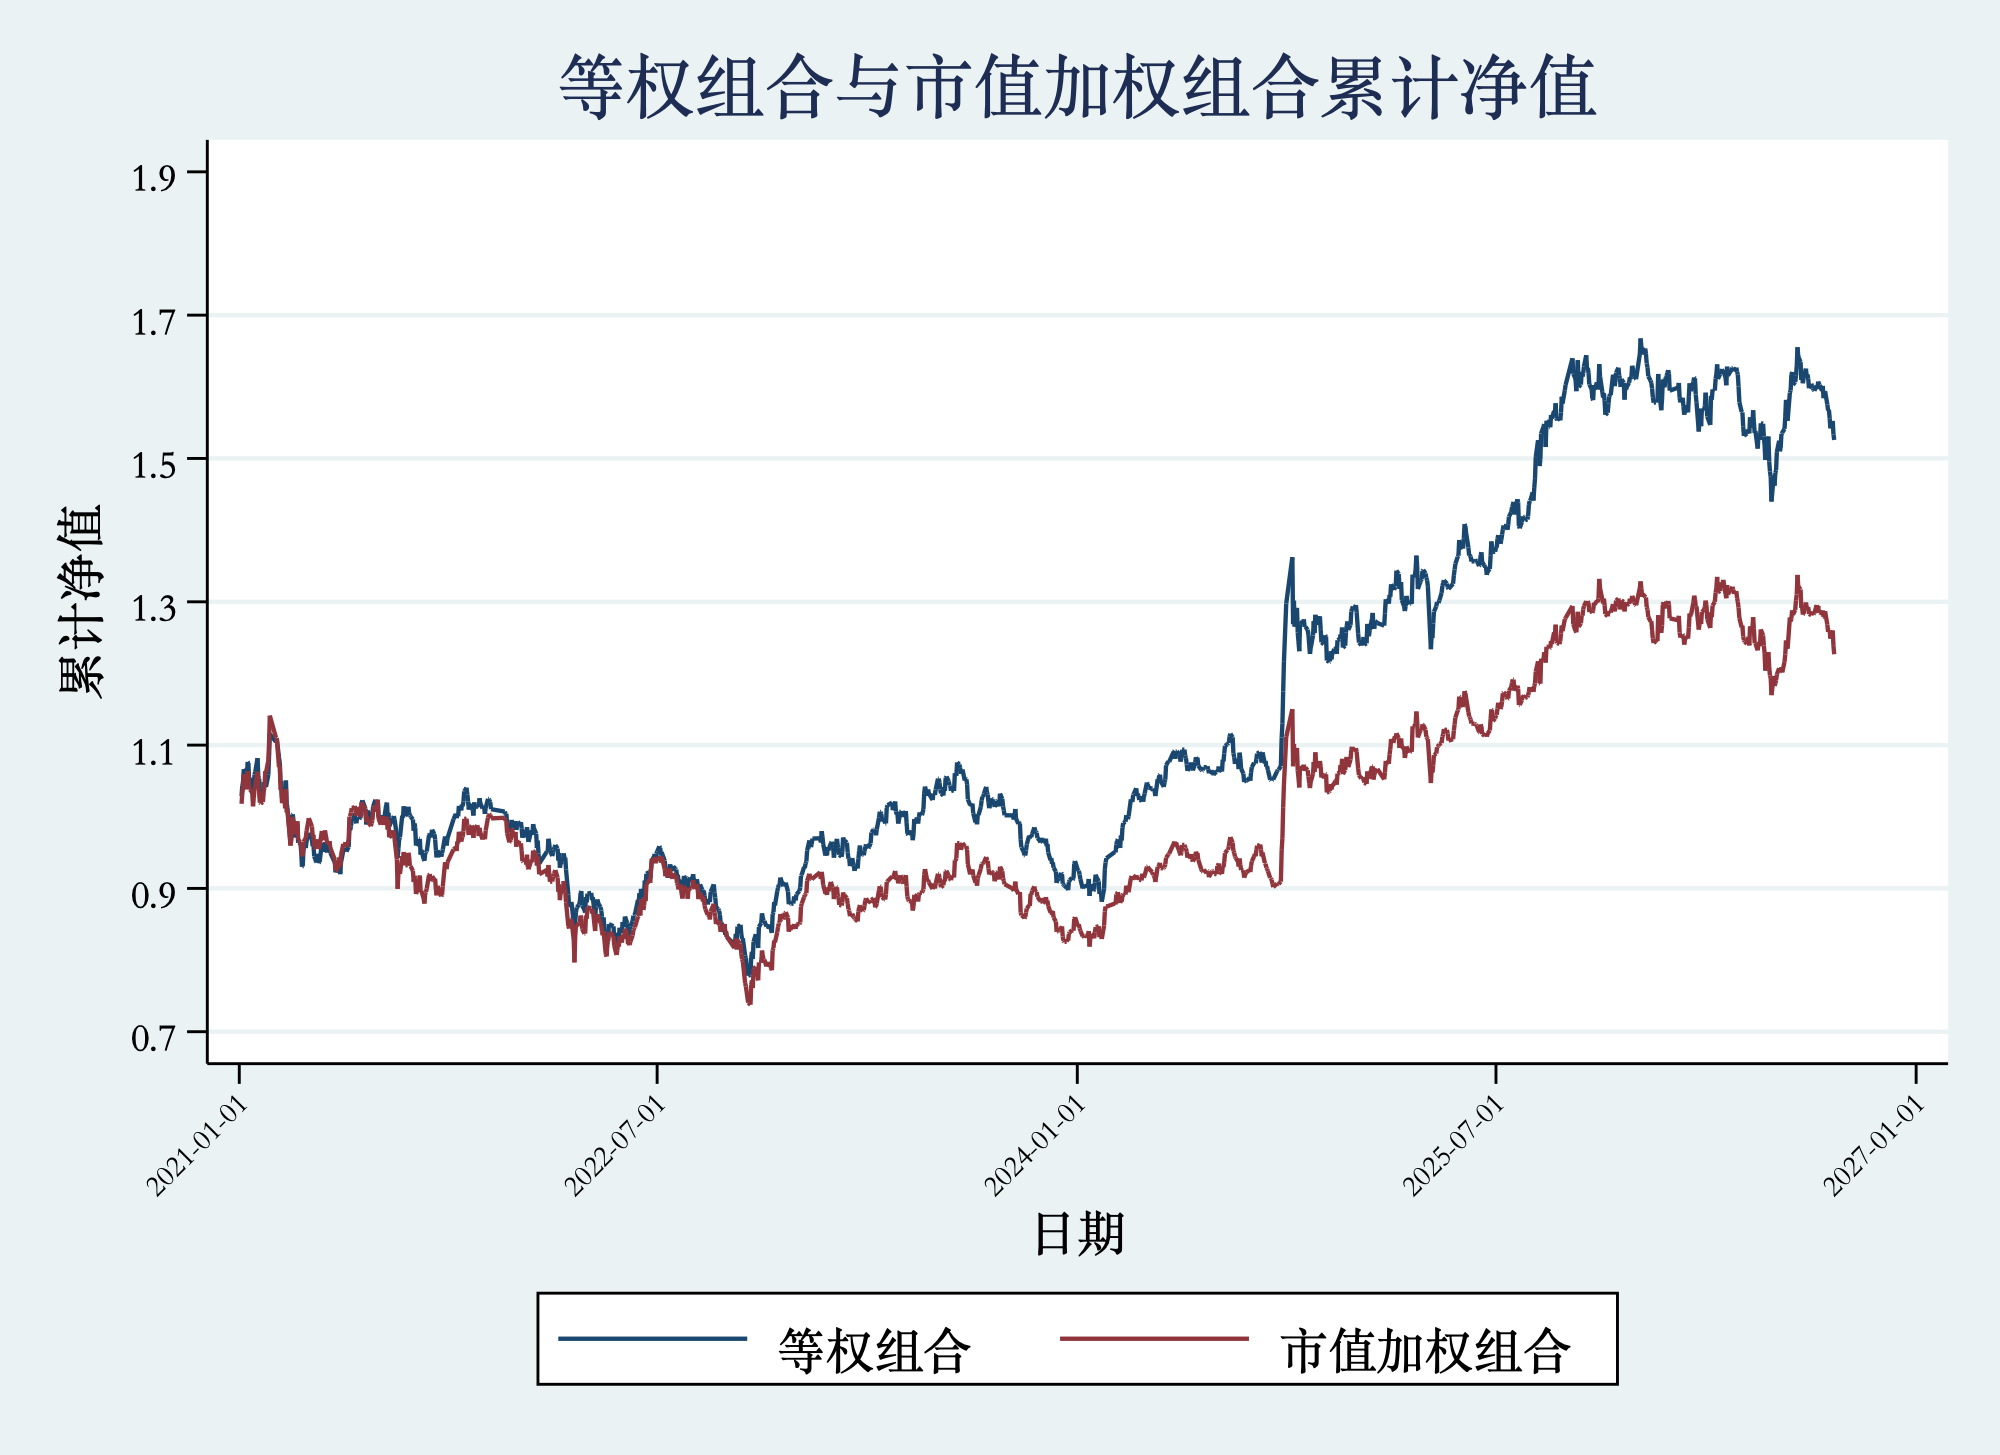

组合表现如下：

| 组合 | 有效日数 | 评价起点 | 评价终点 | 期末净值 | 几何年化收益率（%） | 年化波动率（%） | 最大回撤（%） | 最大回撤日 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 等权组合 | 1369 | 2021-01-04 | 2026-09-16 | 1.526 | 8.089 | 17.981 | 30.231 | 2022-10-28 |
| 市值加权组合 | 1369 | 2021-01-04 | 2026-09-16 | 1.227 | 3.835 | 17.729 | 35.351 | 2022-10-31 |

市值加权组合的平均权重如下：

| 股票代码 | 简称 | 平均市值权重（%） |
| --- | --- | --- |
| 600519 | 贵州茅台 | 27.720 |
| 601398 | 工商银行 | 19.890 |
| 300750 | 宁德时代 | 14.780 |
| 600900 | 长江电力 | 7.680 |
| 601318 | 中国平安 | 7.340 |
| 002594 | 比亚迪 | 6.350 |
| 000333 | 美的集团 | 6.150 |
| 601899 | 紫金矿业 | 4.300 |
| 600276 | 恒瑞医药 | 4.130 |
| 000063 | 中兴通讯 | 1.660 |

### Step 3：结果解读

组合结果显示，等权组合期末净值为 1.526，几何年化收益率约为 8.09%，年化波动率约为 17.98%，最大回撤约为 30.23%。市值加权组合期末净值为 1.227，几何年化收益率约为 3.84%，年化波动率约为 17.73%，最大回撤约为 35.35%。两类组合的年化波动率接近，但等权组合收益更高、最大回撤更小。

市值权重分布解释了部分差异。市值加权组合平均权重最高的是贵州茅台，约为 27.72%；其次是工商银行，约为 19.89%；宁德时代约为 14.78%。这意味着市值加权组合更受少数大市值股票影响。等权组合则给紫金矿业、宁德时代、比亚迪等高弹性股票更高相对权重，因此在样本期内取得更高累计净值。

对 2024 年上半年进行异常跳变检查后，没有发现绝对值超过 5% 的组合日收益。该阶段最大等权组合日收益不足以造成图形中的垂直跳空，因此若出现突兀抬升，应优先检查是否按日期排序、是否有重复日期，以及是否从中间数据继续运行。

核心发现：

- 等权组合在样本期内收益更高，最大回撤更低。
- 市值加权组合权重集中在贵州茅台、工商银行、宁德时代等大市值股票。
- 两类组合波动率接近，但权重结构导致累计净值差异明显。
- 本结果是事后选定样本的描述性分析，不等同于真实可实施策略或未来收益预测。

## 6. 总体结论

本报告基于 CSMAR 日个股回报率数据，对 10 只 A 股股票的收益、风险、相关性和组合表现进行了分析。数据处理上，主键唯一、核心字段完整；对于个股交易日缺口，本报告没有将缺口后的跨期收益直接作为单日收益，而是将其剔除出日收益率统计和组合分析。收益率使用考虑现金红利再投资的 `Dretwd`，并用复权可比价格 `Adjprcwd` 进行了核验。不复权收盘价只用于价格时序图，不用于收益率计算。

个股层面，宁德时代、中兴通讯和紫金矿业波动较高，工商银行和长江电力波动较低；比亚迪和宁德时代相关性最高，说明同行业或产业链相关股票更容易同涨同跌。组合层面，等权组合期末净值为 1.526，几何年化收益率约为 8.09%，最大回撤约为 30.23%；市值加权组合期末净值为 1.227，几何年化收益率约为 3.84%，最大回撤约为 35.35%。等权组合表现较好，主要与其对中小权重、高弹性股票给予更高相对配置有关；市值加权组合则更受贵州茅台、工商银行等大市值股票影响。

本分析仍有局限。首先，样本股票是事后选定的 10 只代表性股票，不能代表全部 A 股市场。其次，组合计算忽略交易成本、再平衡成本和真实可交易性。最后，样本期包含特定市场环境，历史表现不能直接外推为未来收益。